In [1]:
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
df=pd.read_csv('rossmann_train.csv',low_memory=False)

In [68]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


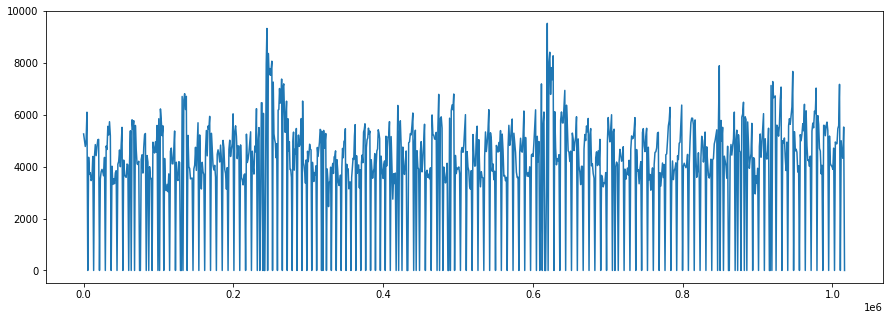

In [69]:
df[df['Store']==1]['Sales'].plot(figsize=(15,5));

In [70]:
(df[df['Store']==1]['Sales']==0).sum()

161

In [71]:
store1=df[df['Store']==1].copy()

<AxesSubplot:>

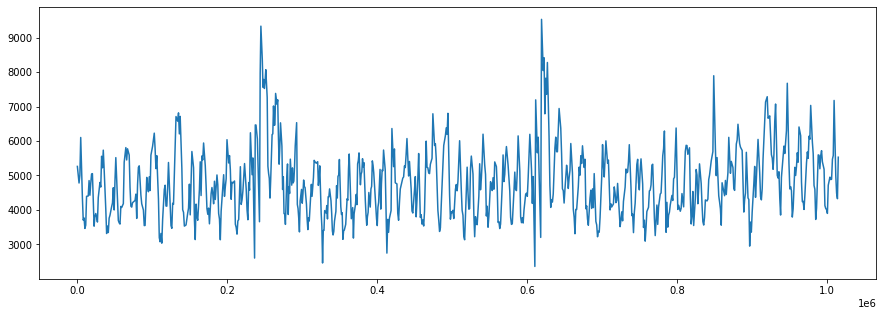

In [72]:
store1[store1['Open']>0]['Sales'].plot(figsize=(15,5))

In [73]:
sales0=store1[store1['Sales']==0].index
customers0=store1[store1['Customers']==0].index
store_closed=store1[store1['Open']==0].index
print(np.all(sales0==customers0))
print(np.all(store_closed==customers0))

True
True


In [74]:
store1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1115,1,4,2015-07-30,5020,546,1,1,0,1
2230,1,3,2015-07-29,4782,523,1,1,0,1
3345,1,2,2015-07-28,5011,560,1,1,0,1
4460,1,1,2015-07-27,6102,612,1,1,0,1


In [75]:
store1['Date']=pd.to_datetime(store1['Date'])

In [76]:
store1.set_index('Date',inplace=True)

In [77]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


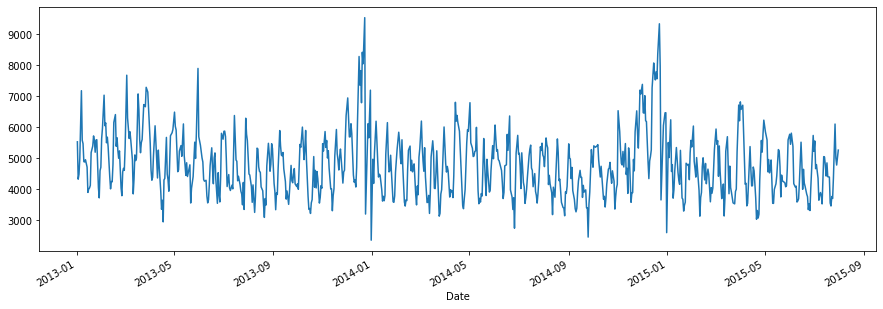

In [78]:
store1[store1['Customers']>0]['Sales'].plot(figsize=(15,5));

In [79]:
df_p=store1[['Sales']].copy()

In [80]:
df_p['Date']=df_p.index

In [81]:
df_p.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [82]:
df_p.tail()

,Sales,Date
Date,,
2013-01-05,4997,2013-01-05
2013-01-04,4486,2013-01-04
2013-01-03,4327,2013-01-03
2013-01-02,5530,2013-01-02
2013-01-01,0,2013-01-01


In [83]:
df_p.sort_index(inplace=True)

In [84]:
df_p.head(20)

,Sales,Date
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05
2013-01-06,0,2013-01-06
2013-01-07,7176,2013-01-07
2013-01-08,5580,2013-01-08
2013-01-09,5471,2013-01-09


In [85]:
df_p.tail()

,Sales,Date
Date,,
2015-07-27,6102,2015-07-27
2015-07-28,5011,2015-07-28
2015-07-29,4782,2015-07-29
2015-07-30,5020,2015-07-30
2015-07-31,5263,2015-07-31


In [86]:
df_p.columns=['y','ds']

In [26]:
m=Prophet()

In [27]:
m.fit(df_p)

09:18:47 - cmdstanpy - INFO - Chain [1] start processing
09:18:58 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
future=m.make_future_dataframe(periods=365)

In [29]:
future.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [30]:
future.tail()

,ds
1302,2016-07-26
1303,2016-07-27
1304,2016-07-28
1305,2016-07-29
1306,2016-07-30


In [31]:
forecast=m.predict(future)

In [32]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1302,2016-07-26,3733.923652,3141.895316,5865.267590,3712.556526,3757.510268,713.230065,713.230065,713.230065,706.314172,706.314172,706.314172,6.915893,6.915893,6.915893,0.0,0.0,0.0,4447.153717
1303,2016-07-27,3733.699678,2780.096216,5581.914673,3712.289735,3757.365009,502.386554,502.386554,502.386554,510.547977,510.547977,510.547977,-8.161423,-8.161423,-8.161423,0.0,0.0,0.0,4236.086232
1304,2016-07-28,3733.475704,2367.010264,5308.838749,3712.022944,3757.209111,126.418902,126.418902,126.418902,151.288442,151.288442,151.288442,-24.869540,-24.869540,-24.869540,0.0,0.0,0.0,3859.894606
1305,2016-07-29,3733.251731,2847.692140,5824.236979,3711.756153,3757.043698,530.751516,530.751516,530.751516,573.626215,573.626215,573.626215,-42.874700,-42.874700,-42.874700,0.0,0.0,0.0,4264.003246
1306,2016-07-30,3733.027757,3217.350271,6090.020575,3711.489363,3756.893132,937.229442,937.229442,937.229442,999.052085,999.052085,999.052085,-61.822642,-61.822642,-61.822642,0.0,0.0,0.0,4670.257199


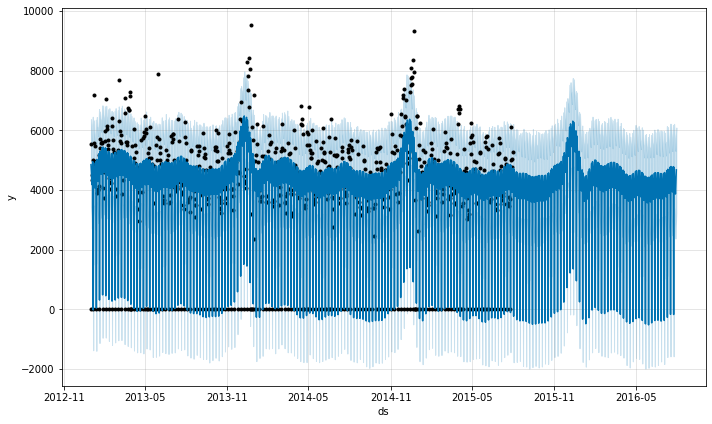

In [34]:
m.plot(forecast);

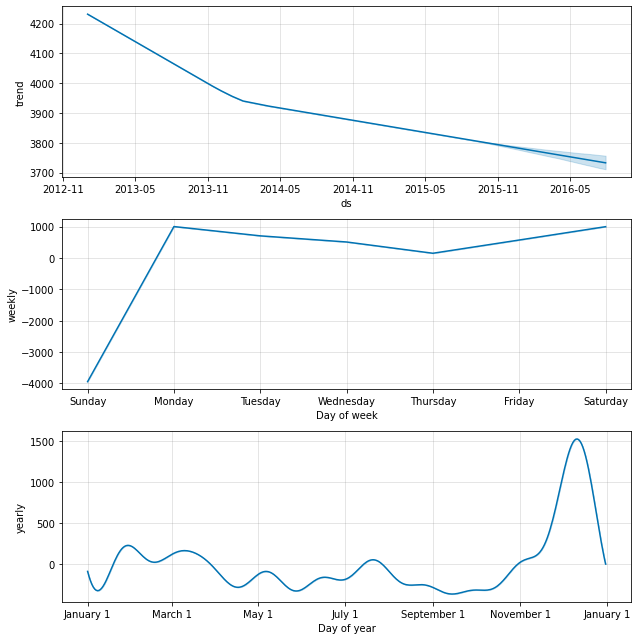

In [35]:
m.plot_components(forecast);

Model Open Days Only

In [36]:
df_p2=store1[store1['Open']>0][['Sales']].copy()
df_p2['Date']=df_p2.index

In [37]:
df_p2.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [38]:
df_p2.columns=['y','ds']

09:21:41 - cmdstanpy - INFO - Chain [1] start processing
09:21:42 - cmdstanpy - INFO - Chain [1] done processing


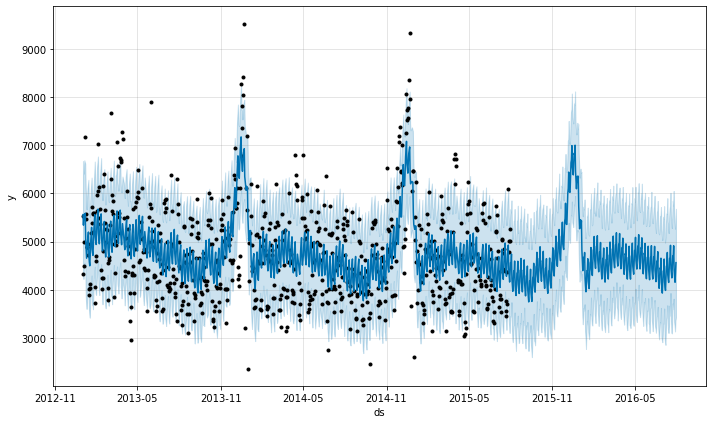

In [41]:
m2=Prophet()
m2.fit(df_p2)
future2=m2.make_future_dataframe(periods=365)
forecast2=m2.predict(future2)
m2.plot(forecast2);

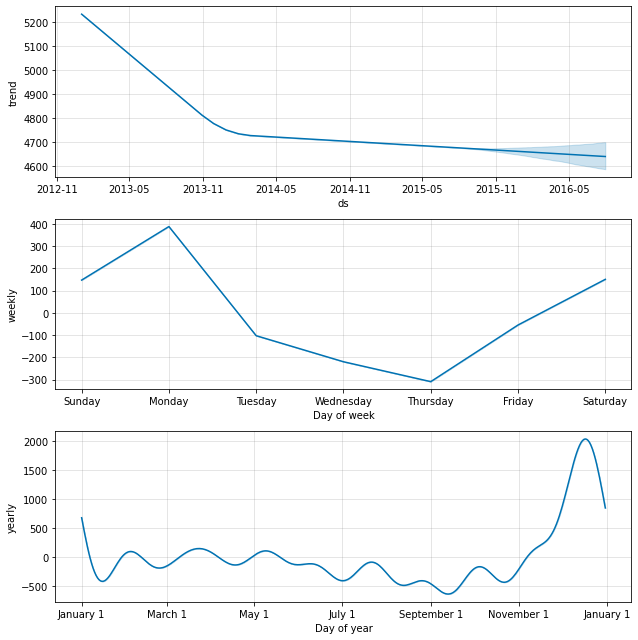

In [42]:
m2.plot_components(forecast2);

Add Holidays

In [43]:
m3=Prophet()

In [45]:
m3.add_country_holidays(country_name='US')

In [46]:
m3.fit(df_p2)

09:22:22 - cmdstanpy - INFO - Chain [1] start processing
09:22:22 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
futures3=m3.make_future_dataframe(periods=365)

In [51]:
forecast3=m3.predict(futures3)

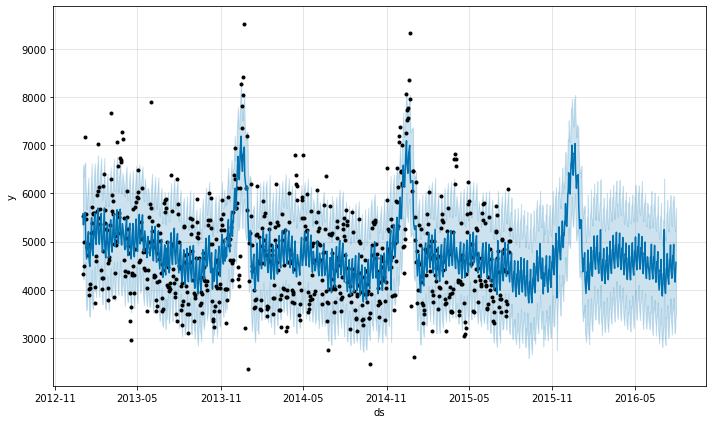

In [52]:
m3.plot(forecast3);

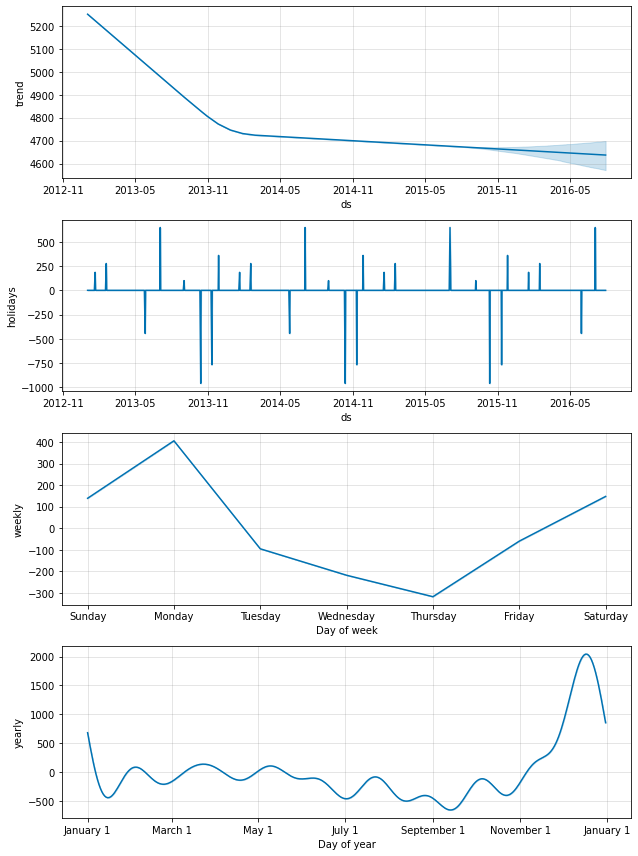

In [53]:
m3.plot_components(forecast3);

Add Regressors

In [88]:
set(store1['StateHoliday'])

{'0', 'a', 'b', 'c'}

In [89]:
set(store1['SchoolHoliday'])

{0, 1}

In [90]:
store1

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1
...,...,...,...,...,...,...,...,...
2013-01-05,1,6,4997,635,1,0,0,1
2013-01-04,1,5,4486,619,1,0,0,1
2013-01-03,1,4,4327,578,1,0,0,1


In [92]:
df_p['Open']=store1['Open']
df_p['promo']=store1['Promo']
df_p[['SH1','SH2','SH3']]=pd.get_dummies(store1['StateHoliday'],drop_first=True)
df_p['SchoolHoliday']=store1['SchoolHoliday']

In [93]:
df_p.head(20)

,y,ds,Open,promo,SH1,SH2,SH3,SchoolHoliday
Date,,,,,,,,
2013-01-01,0,2013-01-01,0,0,1,0,0,1
2013-01-02,5530,2013-01-02,1,0,0,0,0,1
2013-01-03,4327,2013-01-03,1,0,0,0,0,1
2013-01-04,4486,2013-01-04,1,0,0,0,0,1
2013-01-05,4997,2013-01-05,1,0,0,0,0,1
2013-01-06,0,2013-01-06,0,0,0,0,0,1
2013-01-07,7176,2013-01-07,1,1,0,0,0,1
2013-01-08,5580,2013-01-08,1,1,0,0,0,1
2013-01-09,5471,2013-01-09,1,1,0,0,0,1


In [96]:
m4=Prophet()
m4.add_regressor('Open',mode='multiplicative')
m4.add_regressor('promo',mode='additive')
m4.add_regressor('SH1',mode='additive')
m4.add_regressor('SH2',mode='additive')
m4.add_regressor('SH3',mode='additive')
m4.add_regressor('SchoolHoliday',mode='additive')
m4.fit(df_p)

09:57:47 - cmdstanpy - INFO - Chain [1] start processing
09:58:01 - cmdstanpy - INFO - Chain [1] done processing


In [98]:
futures4=m4.make_future_dataframe(periods=365)

In [100]:
train_idx=futures4['ds'].isin(df_p.index)
test_idx=~train_idx

In [103]:
regressors=['Open','promo','SH1','SH2','SH3','SchoolHoliday']
for r in regressors:
    futures4.loc[train_idx,r]=df_p[r].tolist()

In [106]:
futures4.loc[test_idx,'Open']=\
    futures4.loc[test_idx,'ds'].apply(lambda x:1.0 *(x.weekday() !=6))
    
for r in regressors [1:]:
    futures4.loc[test_idx,r]=df_p.iloc[-365:][r].to_list()

In [107]:
futures4.tail(10)

,ds,Open,promo,SH1,SH2,SH3,SchoolHoliday
1297,2016-07-21,1.0,0.0,0.0,0.0,0.0,0.0
1298,2016-07-22,1.0,0.0,0.0,0.0,0.0,0.0
1299,2016-07-23,1.0,0.0,0.0,0.0,0.0,0.0
1300,2016-07-24,0.0,0.0,0.0,0.0,0.0,0.0
1301,2016-07-25,1.0,0.0,0.0,0.0,0.0,0.0
1302,2016-07-26,1.0,1.0,0.0,0.0,0.0,1.0
1303,2016-07-27,1.0,1.0,0.0,0.0,0.0,1.0
1304,2016-07-28,1.0,1.0,0.0,0.0,0.0,1.0
1305,2016-07-29,1.0,1.0,0.0,0.0,0.0,1.0
1306,2016-07-30,1.0,1.0,0.0,0.0,0.0,1.0


In [108]:
forecast4=m4.predict(futures4)

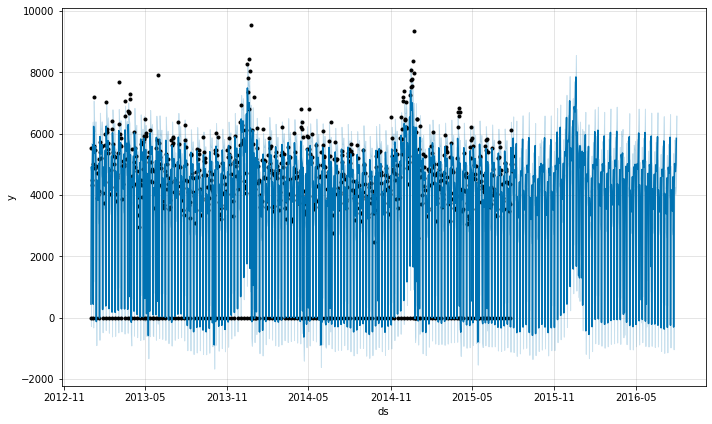

In [110]:
m4.plot(forecast4);

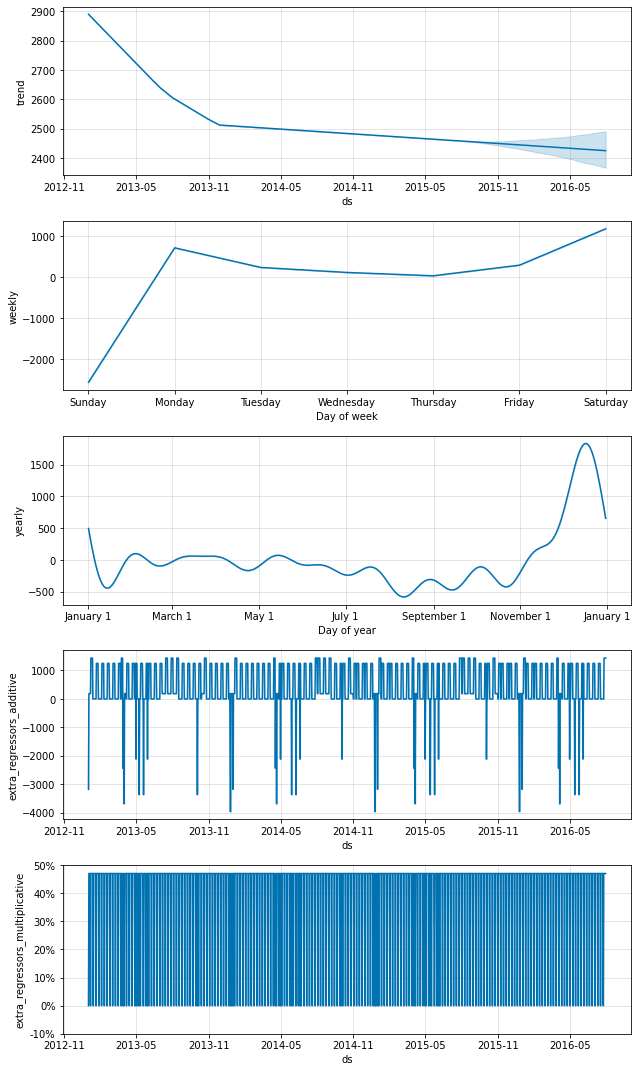

In [111]:
m4.plot_components(forecast4);

Cross Validation

In [112]:
from prophet.diagnostics import cross_validation

In [114]:
df_cv=cross_validation(
    m,
    initial='730 days',
    period='30 days',
    horizon='60 days'
)

  0%|          | 0/6 [00:00<?, ?it/s]

10:16:38 - cmdstanpy - INFO - Chain [1] start processing
10:16:39 - cmdstanpy - INFO - Chain [1] done processing
10:16:41 - cmdstanpy - INFO - Chain [1] start processing
10:16:41 - cmdstanpy - INFO - Chain [1] done processing
10:16:44 - cmdstanpy - INFO - Chain [1] start processing
10:16:44 - cmdstanpy - INFO - Chain [1] done processing
10:16:46 - cmdstanpy - INFO - Chain [1] start processing
10:16:47 - cmdstanpy - INFO - Chain [1] done processing
10:16:48 - cmdstanpy - INFO - Chain [1] start processing
10:16:49 - cmdstanpy - INFO - Chain [1] done processing
10:16:51 - cmdstanpy - INFO - Chain [1] start processing
10:16:51 - cmdstanpy - INFO - Chain [1] done processing


In [115]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-03,4610.222383,3148.807940,6202.483588,5023,2015-01-02
1,2015-01-04,-444.404895,-1852.328917,1062.272398,0,2015-01-02
2,2015-01-05,4572.787881,3074.577817,5966.980307,6239,2015-01-02
3,2015-01-06,4188.120621,2740.050357,5712.985086,4574,2015-01-02
4,2015-01-07,3950.166158,2412.717491,5483.904706,4796,2015-01-02
...,...,...,...,...,...,...
355,2015-07-27,4767.262334,3433.005698,6293.883904,6102,2015-06-01
356,2015-07-28,4442.712196,3018.407369,5960.160219,5011,2015-06-01
357,2015-07-29,4228.024571,2870.981824,5710.496498,4782,2015-06-01
358,2015-07-30,3852.353607,2479.457504,5297.669143,5020,2015-06-01


In [117]:
from prophet.diagnostics import performance_metrics

In [118]:
pm=performance_metrics(df_cv)
pm

,horizon,mse,rmse,mae,mdape,smape,coverage
0,6 days,2.224656e+06,1491.528071,920.510113,0.137941,0.550565,0.805556
1,7 days,1.586613e+06,1259.608206,758.243469,0.131331,0.491704,0.833333
2,8 days,1.459956e+06,1208.286234,704.083904,0.123455,0.486003,0.888889
3,9 days,1.166266e+06,1079.937912,688.603436,0.145110,0.453495,0.916667
4,10 days,5.031827e+05,709.353734,576.770545,0.154510,0.459905,0.944444
5,11 days,4.942255e+05,703.011705,567.727816,0.146653,0.403036,0.944444
6,12 days,8.554970e+05,924.930818,631.333713,0.146653,0.449852,0.944444
7,13 days,8.256523e+05,908.654106,603.918649,0.135675,0.441364,0.944444
8,14 days,7.820015e+05,884.308459,565.652624,0.123856,0.432790,0.944444
9,15 days,6.553336e+05,809.526773,496.925593,0.102842,0.414352,0.972222


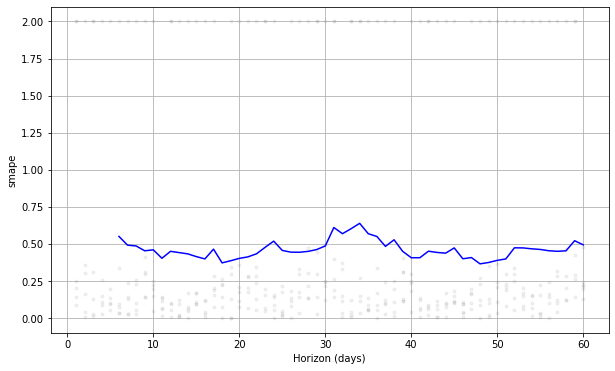

In [120]:
from prophet.plot import plot_cross_validation_metric
plot_cross_validation_metric(df_cv,metric='smape');

In [121]:
df_cv2=cross_validation(
    m2,
    initial='730 days',
    period='30 days',
    horizon='60 days'
)

  0%|          | 0/6 [00:00<?, ?it/s]

10:25:28 - cmdstanpy - INFO - Chain [1] start processing
10:25:29 - cmdstanpy - INFO - Chain [1] done processing
10:25:31 - cmdstanpy - INFO - Chain [1] start processing
10:25:32 - cmdstanpy - INFO - Chain [1] done processing
10:25:34 - cmdstanpy - INFO - Chain [1] start processing
10:25:34 - cmdstanpy - INFO - Chain [1] done processing
10:25:36 - cmdstanpy - INFO - Chain [1] start processing
10:25:37 - cmdstanpy - INFO - Chain [1] done processing
10:25:39 - cmdstanpy - INFO - Chain [1] start processing
10:25:39 - cmdstanpy - INFO - Chain [1] done processing
10:25:42 - cmdstanpy - INFO - Chain [1] start processing
10:25:42 - cmdstanpy - INFO - Chain [1] done processing


In [122]:
pm2=performance_metrics(df_cv2)


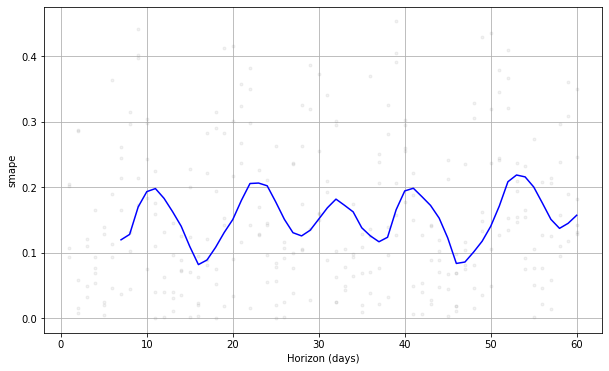

In [123]:
plot_cross_validation_metric(df_cv2,metric='smape');

In [124]:
df_cv3=cross_validation(
    m3,
    initial='730 days',
    period='30 days',
    horizon='60 days'
)
pm3=performance_metrics(df_cv3)


  0%|          | 0/6 [00:00<?, ?it/s]

10:30:04 - cmdstanpy - INFO - Chain [1] start processing
10:30:11 - cmdstanpy - INFO - Chain [1] done processing
10:30:13 - cmdstanpy - INFO - Chain [1] start processing
10:30:14 - cmdstanpy - INFO - Chain [1] done processing
10:30:16 - cmdstanpy - INFO - Chain [1] start processing
10:30:17 - cmdstanpy - INFO - Chain [1] done processing
10:30:20 - cmdstanpy - INFO - Chain [1] start processing
10:30:21 - cmdstanpy - INFO - Chain [1] done processing
10:30:25 - cmdstanpy - INFO - Chain [1] start processing
10:30:25 - cmdstanpy - INFO - Chain [1] done processing
10:30:28 - cmdstanpy - INFO - Chain [1] start processing
10:30:29 - cmdstanpy - INFO - Chain [1] done processing


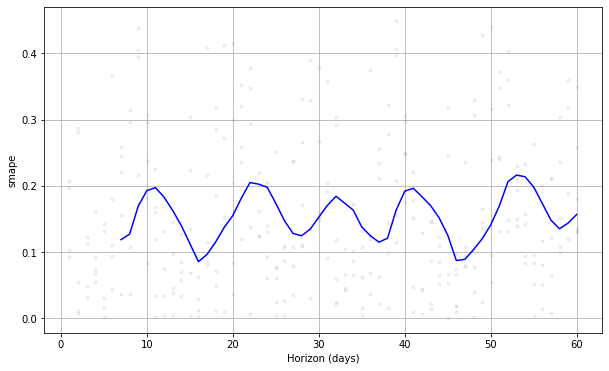

In [125]:
plot_cross_validation_metric(df_cv3,metric='smape');

In [126]:
df_cv4=cross_validation(
    m4,
    initial='730 days',
    period='30 days',
    horizon='60 days'
)
pm4=performance_metrics(df_cv4)


  0%|          | 0/6 [00:00<?, ?it/s]

10:31:08 - cmdstanpy - INFO - Chain [1] start processing
10:31:09 - cmdstanpy - INFO - Chain [1] done processing
10:31:11 - cmdstanpy - INFO - Chain [1] start processing
10:31:12 - cmdstanpy - INFO - Chain [1] done processing
10:31:14 - cmdstanpy - INFO - Chain [1] start processing
10:31:15 - cmdstanpy - INFO - Chain [1] done processing
10:31:17 - cmdstanpy - INFO - Chain [1] start processing
10:31:18 - cmdstanpy - INFO - Chain [1] done processing
10:31:21 - cmdstanpy - INFO - Chain [1] start processing
10:31:21 - cmdstanpy - INFO - Chain [1] done processing
10:31:24 - cmdstanpy - INFO - Chain [1] start processing
10:31:25 - cmdstanpy - INFO - Chain [1] done processing


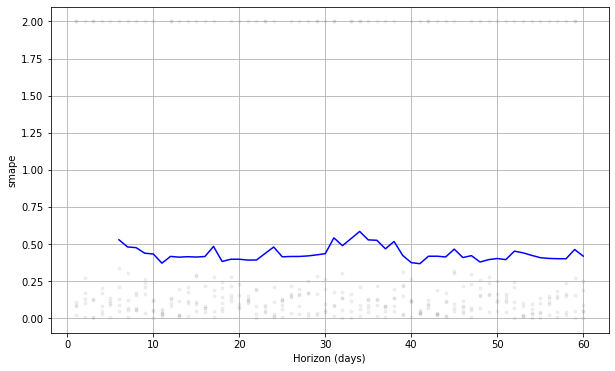

In [127]:
plot_cross_validation_metric(df_cv4,metric='smape');

In [128]:
pm['smape'].mean(),pm2['smape'].mean(),pm3['smape'].mean(),pm4['smape'].mean()

(0.461632034378287,
 0.15381809346394218,
 0.15399995159455138,
 0.43564316966318384)

Changepoint Detection

In [129]:
from prophet.plot import add_changepoints_to_plot

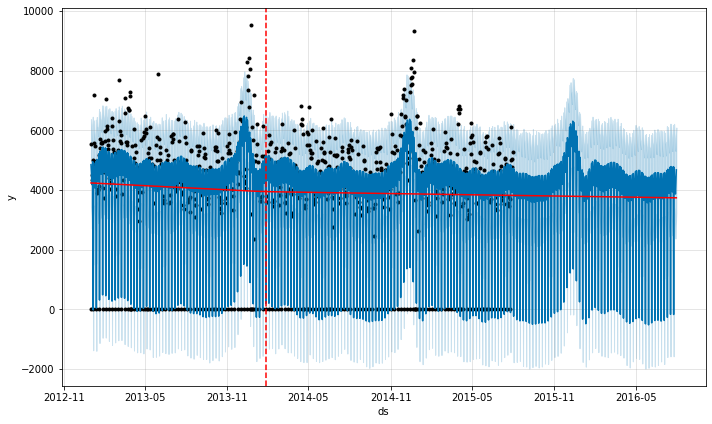

In [130]:
fig= m.plot(forecast)
a=add_changepoints_to_plot(fig.gca(),m,forecast)

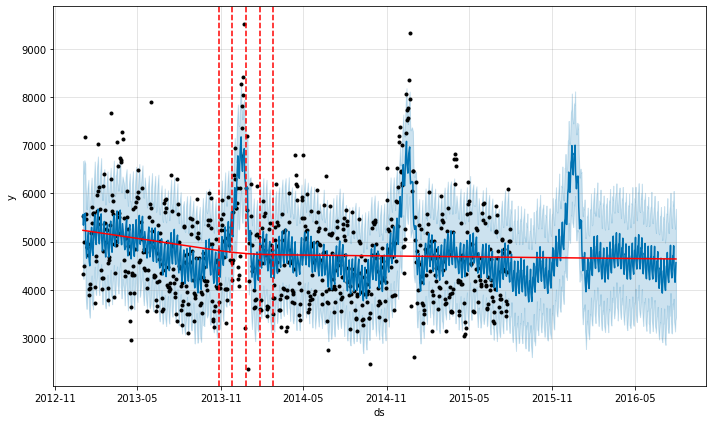

In [131]:
fig=m2.plot(forecast2)
a=add_changepoints_to_plot(fig.gca(),m2,forecast2)

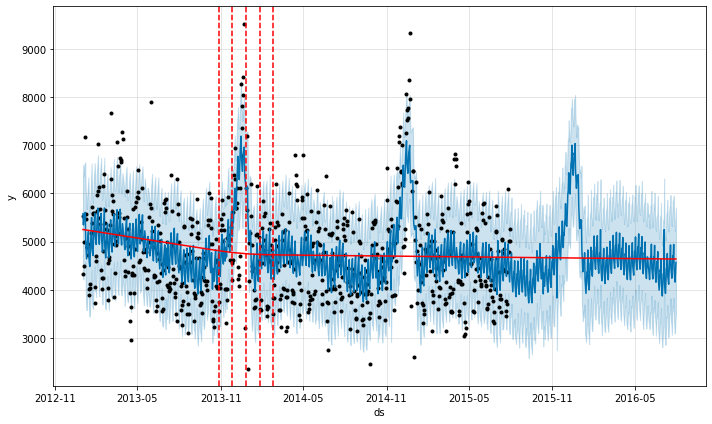

In [132]:
fig=m3.plot(forecast3)
a=add_changepoints_to_plot(fig.gca(),m3,forecast3)

10:44:25 - cmdstanpy - INFO - Chain [1] start processing
10:44:25 - cmdstanpy - INFO - Chain [1] done processing


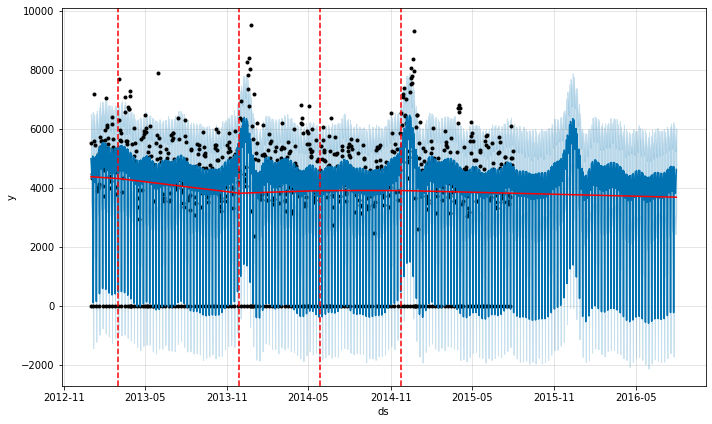

In [133]:
m_a=Prophet(changepoint_prior_scale=.5)
forecast_a=m_a.fit(df_p).predict(future)
fig=m_a.plot(forecast_a)
a=add_changepoints_to_plot(fig.gca(),m_a,forecast_a)

10:46:06 - cmdstanpy - INFO - Chain [1] start processing
10:46:07 - cmdstanpy - INFO - Chain [1] done processing


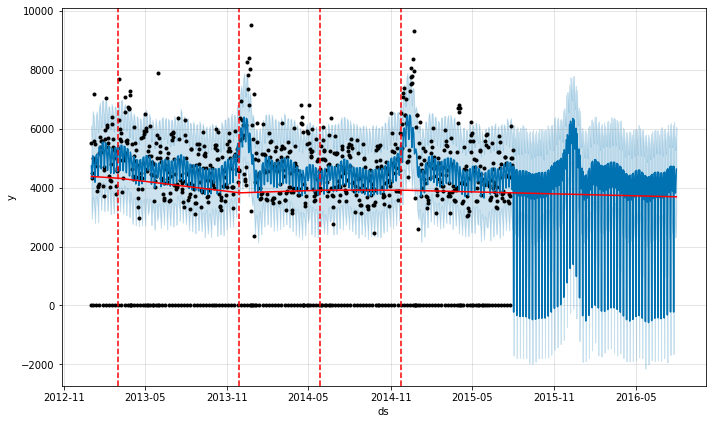

In [135]:
m2_a=Prophet(changepoint_prior_scale=.5)
forecast2_a=m2_a.fit(df_p).predict(future2)
fig=m2_a.plot(forecast2_a)
a=add_changepoints_to_plot(fig.gca(),m2_a,forecast2_a)

10:46:41 - cmdstanpy - INFO - Chain [1] start processing
10:46:41 - cmdstanpy - INFO - Chain [1] done processing


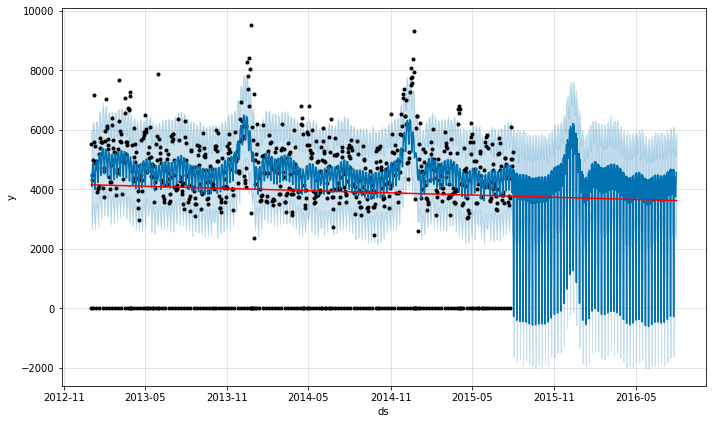

In [136]:
m2_a=Prophet(changepoint_prior_scale=.005)
forecast2_a=m2_a.fit(df_p).predict(future2)
fig=m2_a.plot(forecast2_a)
a=add_changepoints_to_plot(fig.gca(),m2_a,forecast2_a)